# Bayesian Feature Selection Demo (MCMC + Horseshoe Prior)

This notebook demonstrates Bayesian feature selection with the **regularized horseshoe prior** using the tools in this repository.

## Learning goals
1. Understand the math behind horseshoe shrinkage and sparsity.
2. Run MCMC inference with `HorseshoeGLM` on simulated sparse data.
3. Evaluate convergence and posterior behavior with **ArviZ**.
4. Inspect posterior betas and feature selection quality.
5. See a GPU-ready workflow template for real datasets.
6. Practice with hands-on exercises that reveal strengths and limits of the method.


## 1) Mathematical intuition: why the horseshoe induces sparsity

For feature coefficients \(\beta_j\), the (regularized) horseshoe hierarchy is:

\[
\tau \sim \text{Half-Cauchy}(0, \tau_0), \quad
\lambda_j \sim \text{Half-Cauchy}(0, 1), \quad
c^2 \sim \text{Inverse-Gamma}(1,1)
\]
\[
\tilde{\lambda}_j = \sqrt{\frac{c^2\lambda_j^2}{c^2 + \tau^2\lambda_j^2}}, \quad
\beta_j \mid \tau,\lambda_j,c^2 \sim \mathcal{N}(0,\tau^2\tilde{\lambda}_j^2)
\]

For a Gaussian GLM:
\[
\eta_i = \alpha + x_i^\top\beta, \quad
y_i \sim \mathcal{N}(\eta_i, \sigma^2)
\]

### Key sparsity mechanism
- **Global shrinkage** \(\tau\): pushes all coefficients toward zero.
- **Local shrinkage** \(\lambda_j\): lets a few relevant features escape shrinkage.
- **Slab regularization** \(c^2\): avoids unrealistically huge coefficients.

A useful view is the shrinkage factor \(\kappa_j = 1/(1 + \tau^2\lambda_j^2)\):
- Noise features often have \(\kappa_j \approx 1\) (strong shrinkage to near zero).
- True signals often have smaller \(\kappa_j\), preserving non-zero effects.


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

from bayesian_feature_selection import HorseshoeGLM, InferenceConfig

np.random.seed(42)
print('JAX devices:', jax.devices())


JAX devices: [CpuDevice(id=0)]


## 1b) Visualizing the horseshoe prior shape

Before we run inference, it helps to *see* what the horseshoe prior actually looks like. A key property is that the marginal prior on each coefficient β_j is **bimodal-ish**: it has a very sharp spike at zero (encouraging sparsity) and heavy tails (allowing large effects to survive).

Compare it to a standard Gaussian and a Laplace (double-exponential) prior at the same scale. The horseshoe's heavier tails mean it imposes **less bias on true signals** than the Lasso (Laplace) while still driving noise to zero.

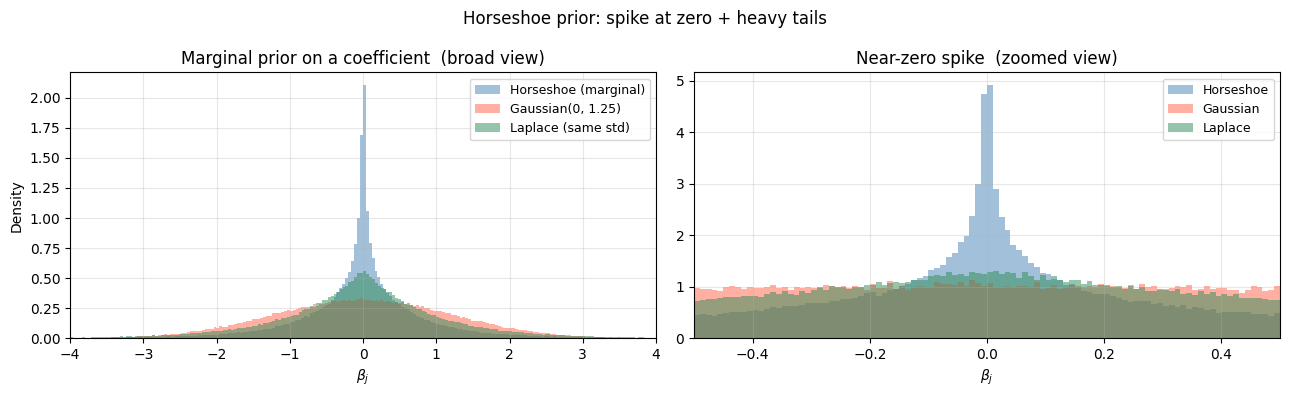

Key takeaways:
  • Horseshoe has the tallest spike near zero → strongest sparsity pressure
  • Horseshoe has the heaviest tails → large true signals suffer less shrinkage bias
  • Laplace (Lasso) is a compromise but shrinks large signals more than horseshoe


In [2]:
# ── Horseshoe marginal prior vs Gaussian vs Laplace ──────────────────────────
# We draw Monte-Carlo samples from the horseshoe hierarchy to approximate
# the marginal distribution of a single beta_j.

rng_prior = np.random.default_rng(0)
n_prior = 200_000

tau_prior   = np.abs(rng_prior.standard_cauchy(n_prior))     # Half-Cauchy(1)
lam_prior   = np.abs(rng_prior.standard_cauchy(n_prior))     # Half-Cauchy(1)
c2_prior    = 1.0 / rng_prior.gamma(1.0, 1.0, n_prior)       # InverseGamma(1,1)
lam_tilde   = np.sqrt(c2_prior * lam_prior**2 /
                      (c2_prior + tau_prior**2 * lam_prior**2))
sigma_j     = tau_prior * lam_tilde
beta_hs     = rng_prior.normal(0, sigma_j)

# Reference priors at similar scale
sigma_ref = float(np.std(beta_hs))   # match std so comparison is fair
beta_gauss = rng_prior.normal(0, sigma_ref, n_prior)
beta_laplace = rng_prior.laplace(0, sigma_ref / np.sqrt(2), n_prior)

clip = 4.0
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# — density on a broad range —
ax = axes[0]
for samples, label, color in [
    (beta_hs,     "Horseshoe (marginal)", "steelblue"),
    (beta_gauss,  f"Gaussian(0, {sigma_ref:.2f})", "tomato"),
    (beta_laplace, "Laplace (same std)",  "seagreen"),
]:
    clipped = samples[np.abs(samples) < clip]
    ax.hist(clipped, bins=200, density=True, alpha=0.5, label=label, color=color)
ax.set_xlim(-clip, clip)
ax.set_xlabel(r"$\beta_j$")
ax.set_ylabel("Density")
ax.set_title("Marginal prior on a coefficient  (broad view)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# — zoom in on the spike near zero —
ax2 = axes[1]
zoom = 0.5
for samples, label, color in [
    (beta_hs,     "Horseshoe", "steelblue"),
    (beta_gauss,  "Gaussian",  "tomato"),
    (beta_laplace, "Laplace",  "seagreen"),
]:
    clipped = samples[np.abs(samples) < zoom]
    ax2.hist(clipped, bins=100, density=True, alpha=0.5, label=label, color=color)
ax2.set_xlim(-zoom, zoom)
ax2.set_xlabel(r"$\beta_j$")
ax2.set_title("Near-zero spike  (zoomed view)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle("Horseshoe prior: spike at zero + heavy tails", fontsize=12)
plt.tight_layout()
plt.show()

print("Key takeaways:")
print("  • Horseshoe has the tallest spike near zero → strongest sparsity pressure")
print("  • Horseshoe has the heaviest tails → large true signals suffer less shrinkage bias")
print("  • Laplace (Lasso) is a compromise but shrinks large signals more than horseshoe")

## 2) Simulated sparse data

We create a high-dimensional-ish problem with many irrelevant features and a few true signals.


n=220, p=60, true non-zero features=6


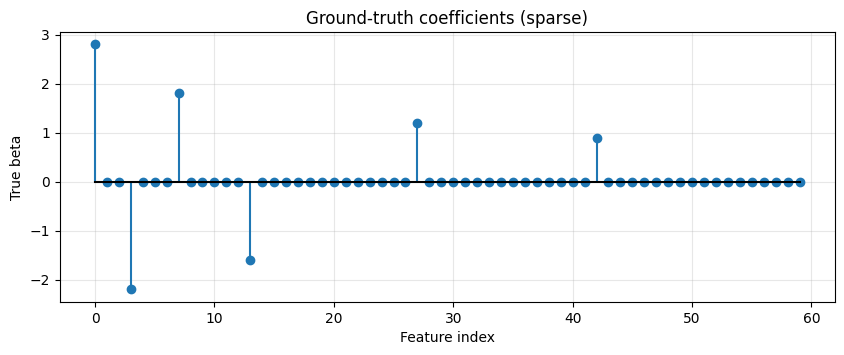

In [3]:
# Simulated data with sparse truth
n, p = 220, 60
n_signal = 6
signal_idx = np.array([0, 3, 7, 13, 27, 42])

X = np.random.normal(size=(n, p))
true_beta = np.zeros(p)
true_beta[signal_idx] = np.array([2.8, -2.2, 1.8, -1.6, 1.2, 0.9])

noise_sd = 1.0
y = X @ true_beta + np.random.normal(0, noise_sd, size=n)

# standardize features for stable inference
X = StandardScaler().fit_transform(X)

print(f'n={n}, p={p}, true non-zero features={len(signal_idx)}')

plt.figure(figsize=(10, 3.5))
plt.stem(np.arange(p), true_beta, basefmt='k-')
plt.title('Ground-truth coefficients (sparse)')
plt.xlabel('Feature index')
plt.ylabel('True beta')
plt.grid(alpha=0.3)
plt.show()


### Signal-to-noise ratio

Before fitting, it's useful to quantify how easy/hard the problem is. The **signal-to-noise ratio (SNR)** measures how large the true signal is relative to the noise variance. Higher SNR → easier recovery.

Signal variance  : 19.803
Noise variance   : 1.000
SNR              : 19.80  (>1 means signal > noise)


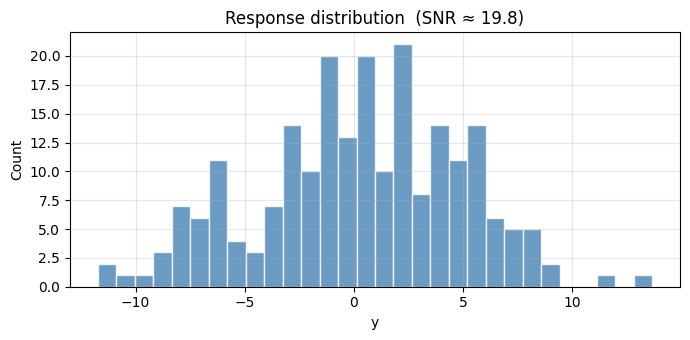

In [4]:
# ── Signal-to-noise ratio and data overview ──────────────────────────────────
signal_var = np.var(X @ true_beta)     # variance explained by the true model
noise_var  = noise_sd**2
snr        = signal_var / noise_var

print(f"Signal variance  : {signal_var:.3f}")
print(f"Noise variance   : {noise_var:.3f}")
print(f"SNR              : {snr:.2f}  (>1 means signal > noise)")

# Distribution of the response
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(y, bins=30, edgecolor='white', color='steelblue', alpha=0.8)
ax.set_xlabel("y")
ax.set_ylabel("Count")
ax.set_title(f"Response distribution  (SNR ≈ {snr:.1f})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3) Fit Horseshoe GLM with MCMC

We focus on MCMC inference (`method='mcmc'`) for full posterior uncertainty.

Rule-of-thumb initialization for global scale:
\[
\tau_0 \approx \frac{p_0}{p-p_0}\cdot\frac{1}{\sqrt{n}}
\]
where \(p_0\) is expected number of relevant features.


In [5]:
expected_p0 = n_signal
scale_global = (expected_p0 / max(p - expected_p0, 1)) / np.sqrt(n)
scale_global = float(np.clip(scale_global, 0.05, 1.0))

use_gpu = any(d.platform == 'gpu' for d in jax.devices())
print('Using GPU?', use_gpu)
print('scale_global:', round(scale_global, 4))

model = HorseshoeGLM(family='gaussian', scale_global=scale_global)
config = InferenceConfig(
    method='mcmc',
    num_warmup=300,
    num_samples=500,
    num_chains=2,
    use_gpu=use_gpu,
    progress_bar=False,
)

model.fit(X, y, config=config)
print('MCMC complete.')


Using GPU? False
scale_global: 0.05


/home/runner/work/bayesian_feature_selection/bayesian_feature_selection/src/bayesian_feature_selection/bayesian_feature_selection.py:178: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(


MCMC complete.


## 4) Feature selection results

We use posterior inclusion from beta samples (default behavior in this repo) and compare with ground truth.


In [6]:
importance = model.get_feature_importance(method='beta', threshold=0.5)
importance = importance.sort_values('beta_inclusion_prob', ascending=False).reset_index(drop=True)

selected_idx = importance.loc[importance['selected'], 'feature_idx'].to_numpy()
true_mask = np.isin(np.arange(p), signal_idx).astype(int)
pred_mask = np.isin(np.arange(p), selected_idx).astype(int)

precision = precision_score(true_mask, pred_mask, zero_division=0)
recall = recall_score(true_mask, pred_mask, zero_division=0)
f1 = f1_score(true_mask, pred_mask, zero_division=0)

print(f'Selected features: {len(selected_idx)}')
print(f'Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}')

show_cols = ['feature_idx', 'beta_mean', 'beta_lower_95', 'beta_upper_95', 'beta_inclusion_prob', 'selected']
display(importance[show_cols].head(12))


Selected features: 55
Precision: 0.109 | Recall: 1.000 | F1: 0.197


,feature_idx,beta_mean,beta_lower_95,beta_upper_95,beta_inclusion_prob,selected
0,0,2.857419,2.727972,2.987006,1.000,True
1,3,-2.210173,-2.331821,-2.073246,1.000,True
2,7,1.865318,1.735031,2.010139,1.000,True
3,13,-1.605179,-1.751578,-1.470116,1.000,True
4,27,1.261590,1.130246,1.402429,1.000,True
5,42,0.771232,0.652499,0.891045,1.000,True
6,1,-0.051850,-0.191930,0.020427,0.765,True
7,33,0.066257,-0.015694,0.217790,0.743,True
8,41,-0.042172,-0.172260,0.031671,0.717,True
9,49,0.033445,-0.029480,0.161648,0.714,True


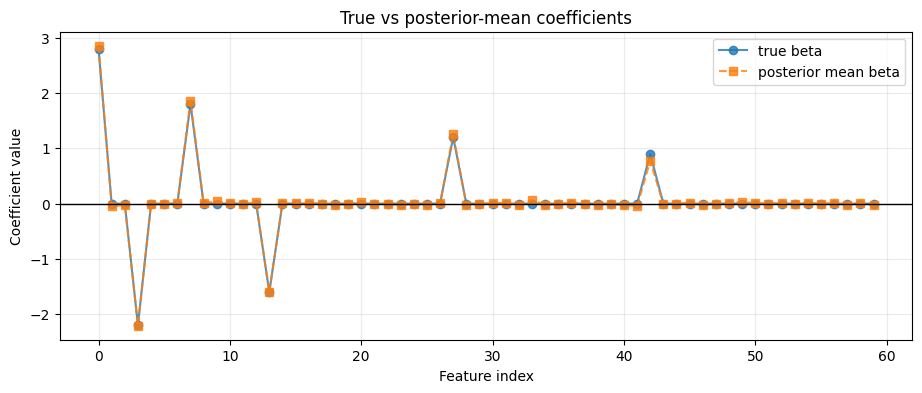

In [7]:
# Visual comparison: posterior mean vs truth
posterior_mean = np.zeros(p)
posterior_mean[importance['feature_idx'].to_numpy()] = importance['beta_mean'].to_numpy()

plt.figure(figsize=(11, 4))
plt.plot(true_beta, 'o-', label='true beta', alpha=0.8)
plt.plot(posterior_mean, 's--', label='posterior mean beta', alpha=0.8)
plt.axhline(0, color='k', lw=1)
plt.title('True vs posterior-mean coefficients')
plt.xlabel('Feature index')
plt.ylabel('Coefficient value')
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### Credible-interval forest plot

A **forest plot** (coefficient plot with 94 % credible intervals) is the standard Bayesian way to show both *point estimates* and *uncertainty* for all coefficients simultaneously.  Features whose interval excludes zero are strong candidates for selection.

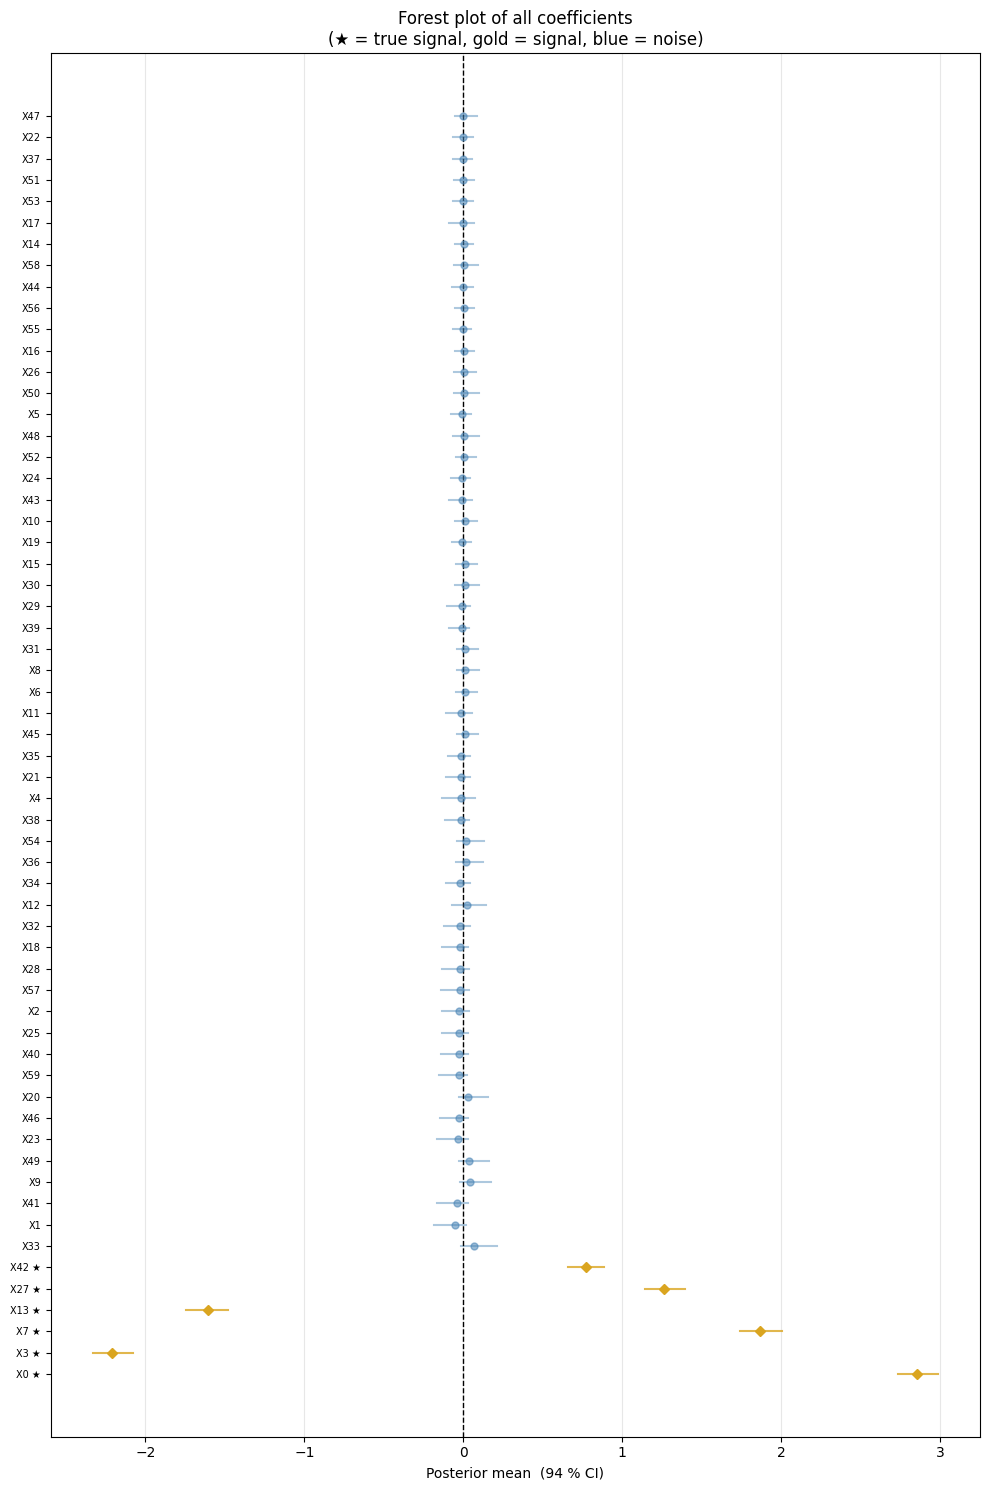

In [8]:
# ── Forest plot: posterior 94% credible intervals ────────────────────────────
# We show all features, coloring true signals gold and noise features grey.
# A vertical line at zero helps read whether the CI excludes zero.

post_samples = model.mcmc.get_samples()["beta"]          # shape (draws, p)
post_mean  = np.array(post_samples.mean(axis=0))
post_lo    = np.array(np.percentile(post_samples, 3, axis=0))
post_hi    = np.array(np.percentile(post_samples, 97, axis=0))

# Sort by |posterior mean| for readability
order = np.argsort(np.abs(post_mean))[::-1]

fig, ax = plt.subplots(figsize=(10, max(5, int(p * 0.25))))
y_pos_all = np.arange(p)

for rank, idx in enumerate(order):
    is_signal = idx in signal_idx
    color  = "goldenrod" if is_signal else "steelblue"
    marker = "D"         if is_signal else "o"
    alpha  = 1.0         if is_signal else 0.55
    ax.plot(post_mean[idx], rank, marker=marker, color=color, ms=5, alpha=alpha, zorder=3)
    ax.plot([post_lo[idx], post_hi[idx]], [rank, rank],
            color=color, lw=1.5, alpha=alpha * 0.8)

ax.axvline(0, color="black", lw=1, ls="--")
ax.set_yticks(range(p))
ax.set_yticklabels([f"X{order[r]}" + (" ★" if order[r] in signal_idx else "")
                    for r in range(p)], fontsize=7)
ax.set_xlabel("Posterior mean  (94 % CI)")
ax.set_title("Forest plot of all coefficients\n(★ = true signal, gold = signal, blue = noise)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 5) ArviZ diagnostics: convergence + beta visualization

We convert NumPyro output to `InferenceData`, inspect R-hat/ESS, and visualize chains/posteriors.


In [9]:
idata = az.from_numpyro(model.mcmc)

# Summaries for convergence diagnostics
summary = az.summary(idata, var_names=['tau', 'c2', 'beta'])
summary.head()


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,0.033,0.013,0.018,0.055,65,62,1.03,0.0013,0.0013
c2,14,4e+01,2.1,36,334,301,1.01,1.8,14
beta[0],2.857,0.067,2.8,3,438,284,1.01,0.003,0.0024
beta[1],-0.052,0.059,-0.17,0.0099,454,428,1.02,0.003,0.0024
beta[2],-0.024,0.043,-0.11,0.023,340,286,1.01,0.0027,0.0027


In [10]:
# Basic convergence checks
rhat_vals = pd.to_numeric(summary['r_hat'], errors='coerce').dropna()
ess_vals = pd.to_numeric(summary['ess_bulk'], errors='coerce').dropna()

rhat_max = float(rhat_vals.max()) if len(rhat_vals) else float('nan')
ess_min = float(ess_vals.min()) if len(ess_vals) else float('nan')

print(f'max R-hat: {rhat_max:.4f}')
print(f'min ESS (bulk): {ess_min:.1f}')
print('Convergence guideline: R-hat near 1.00 and reasonably large ESS.')


max R-hat: 1.0700
min ESS (bulk): 46.0
Convergence guideline: R-hat near 1.00 and reasonably large ESS.


### What do R-hat and ESS mean?

| Statistic | Formula | What it measures | Good value |
|-----------|---------|-----------------|------------|
| **R-hat** (Gelman-Rubin) | Ratio of between-chain to within-chain variance | Whether chains have mixed (converged) | ≈ 1.00 (< 1.01 is excellent, < 1.05 acceptable) |
| **ESS bulk** | Effective Sample Size for the bulk of the distribution | How many *independent* draws the chain is worth for estimating the mean | > 400 (> 100 per chain) |
| **ESS tail** | ESS for quantile estimates (5th/95th percentile) | How well the tails are explored | > 400 |

**If R-hat > 1.05**: run more warmup or increase `num_chains`.  
**If ESS < 100**: increase `num_samples` or use a more efficient sampler.

The cell below plots a *histogram of R-hat values* across all β parameters — a quick health-check for high-dimensional models.

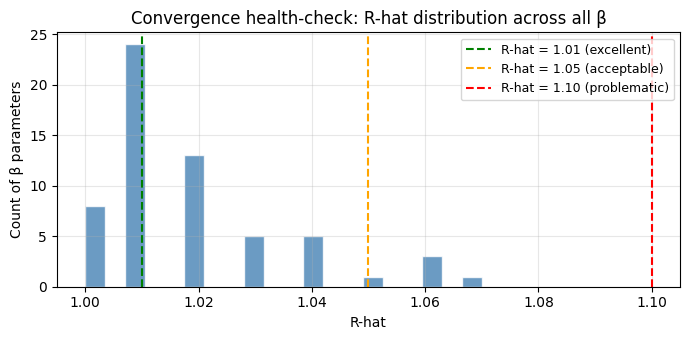

β parameters with R-hat > 1.05: 4 / 60
  → Consider increasing num_warmup or num_samples for better convergence.


In [11]:
# ── R-hat histogram for all β parameters ─────────────────────────────────────
beta_rhat = summary.loc[
    summary.index.str.startswith("beta"), "r_hat"
].astype(float)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(beta_rhat.dropna(), bins=20, edgecolor="white",
        color="steelblue", alpha=0.8)
ax.axvline(1.01, color="green",  ls="--", lw=1.5, label="R-hat = 1.01 (excellent)")
ax.axvline(1.05, color="orange", ls="--", lw=1.5, label="R-hat = 1.05 (acceptable)")
ax.axvline(1.10, color="red",    ls="--", lw=1.5, label="R-hat = 1.10 (problematic)")
ax.set_xlabel("R-hat")
ax.set_ylabel("Count of β parameters")
ax.set_title("Convergence health-check: R-hat distribution across all β")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_bad = (beta_rhat > 1.05).sum()
print(f"β parameters with R-hat > 1.05: {n_bad} / {len(beta_rhat)}")
if n_bad > 0:
    print("  → Consider increasing num_warmup or num_samples for better convergence.")

/home/runner/.local/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)


/home/runner/.local/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)
/home/runner/.local/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)
/home/runner/.local/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype 

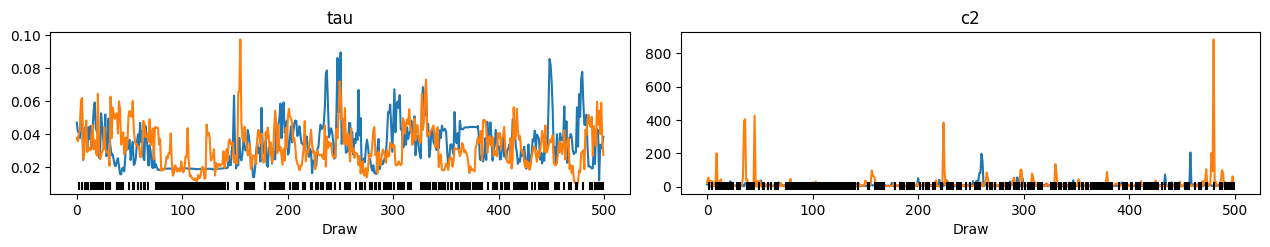

In [12]:
# Trace plot for global parameters
az.plot_trace(idata, var_names=['tau', 'c2'])
plt.tight_layout()
plt.show()


/home/runner/.local/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)
/home/runner/.local/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)
/home/runner/.local/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype 

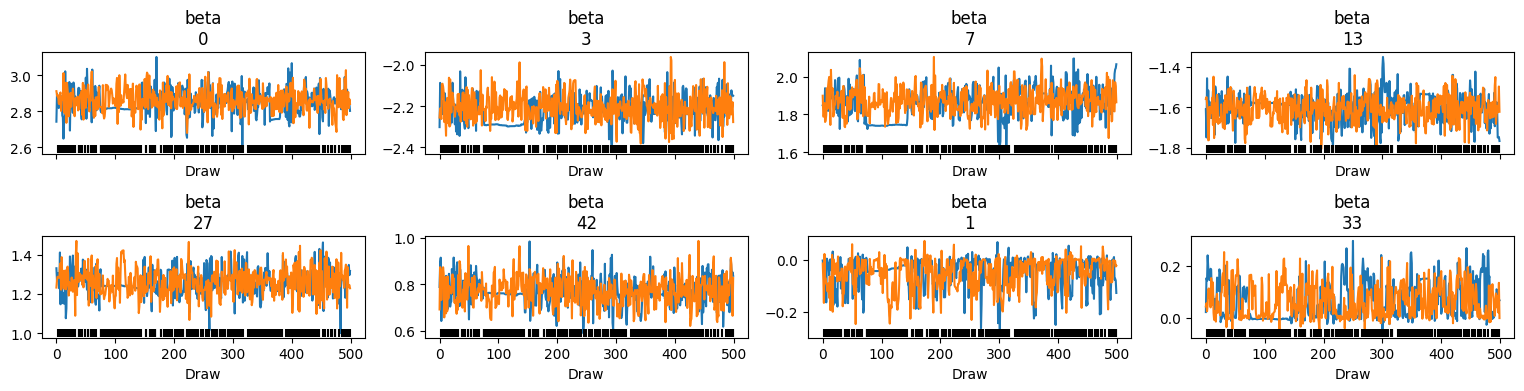

In [13]:
# Beta visualization with ArviZ for top features by inclusion probability
beta_dims = [d for d in idata.posterior['beta'].dims if d not in ('chain', 'draw')]
if len(beta_dims) != 1:
    raise ValueError(
        f"Expected 'beta' to have exactly one non-sampling dimension, found {beta_dims!r}"
    )
beta_dim = beta_dims[0]
if beta_dim not in idata.posterior.coords:
    raise ValueError(f"Derived beta dimension {beta_dim!r} is not present in posterior coords")

top_k = 8
top_features = importance['feature_idx'].head(top_k).tolist()

az.plot_trace(
    idata,
    var_names=['beta'],
    coords={beta_dim: top_features},
)
plt.tight_layout()
plt.show()


## 5b) Shrinkage factor visualization

The **shrinkage factor** κ_j = 1 / (1 + τ² λ_j²) tells us how much each coefficient is pulled toward zero:

- κ_j ≈ 1 → strong shrinkage (noisy feature → stays near zero)  
- κ_j ≈ 0 → weak shrinkage (informative feature → free to be large)

After fitting, we can read the posterior distribution of κ_j for each feature.  True signals should cluster near 0; noise features should cluster near 1.

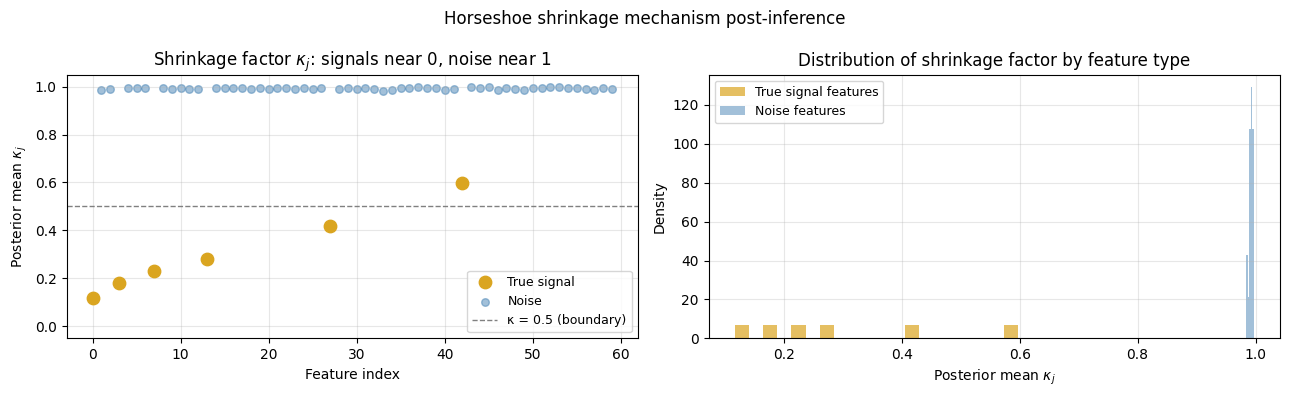

Shrinkage factor summary:
  True signals  — mean κ: 0.304  (want < 0.5)
  Noise features — mean κ: 0.992  (want > 0.5)


In [14]:
# ── Posterior shrinkage factor κ_j for all features ──────────────────────────
samples     = model.mcmc.get_samples()
tau_samp    = np.array(samples["tau"])          # shape (draws,)
lam_samp    = np.array(samples["lambda_local"]) # shape (draws, p)

# κ_j = 1 / (1 + τ² λ_j²)  — posterior mean per feature
kappa_samp  = 1.0 / (1.0 + tau_samp[:, None]**2 * lam_samp**2)
kappa_mean  = kappa_samp.mean(axis=0)  # shape (p,)

is_signal_mask = np.isin(np.arange(p), signal_idx)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# — scatter: kappa vs feature index —
ax = axes[0]
ax.scatter(np.where( is_signal_mask)[0], kappa_mean[ is_signal_mask],
           color="goldenrod", s=80, zorder=3, label="True signal")
ax.scatter(np.where(~is_signal_mask)[0], kappa_mean[~is_signal_mask],
           color="steelblue", s=30, alpha=0.5, label="Noise")
ax.axhline(0.5, color="grey", ls="--", lw=1, label="κ = 0.5 (boundary)")
ax.set_xlabel("Feature index")
ax.set_ylabel(r"Posterior mean $\kappa_j$")
ax.set_title(r"Shrinkage factor $\kappa_j$: signals near 0, noise near 1")
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)

# — histogram split: signals vs noise —
ax2 = axes[1]
ax2.hist(kappa_mean[ is_signal_mask], bins=20, density=True,
         color="goldenrod", alpha=0.7, label="True signal features")
ax2.hist(kappa_mean[~is_signal_mask], bins=20, density=True,
         color="steelblue", alpha=0.5, label="Noise features")
ax2.set_xlabel(r"Posterior mean $\kappa_j$")
ax2.set_ylabel("Density")
ax2.set_title("Distribution of shrinkage factor by feature type")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle("Horseshoe shrinkage mechanism post-inference", fontsize=12)
plt.tight_layout()
plt.show()

print("Shrinkage factor summary:")
print(f"  True signals  — mean κ: {kappa_mean[is_signal_mask].mean():.3f}  (want < 0.5)")
print(f"  Noise features — mean κ: {kappa_mean[~is_signal_mask].mean():.3f}  (want > 0.5)")

## 6) Real data + GPU-ready workflow (optional run)

Below is a compact template using a real dataset (`sklearn` breast cancer data) and automatic GPU detection.

- Set `RUN_REAL_DATA_DEMO = True` to execute.
- Increase MCMC samples/chains for production analysis.


In [15]:
RUN_REAL_DATA_DEMO = False

if RUN_REAL_DATA_DEMO:
    ds = load_breast_cancer()
    X_real = StandardScaler().fit_transform(ds.data)
    y_real = ds.target.astype(float)

    use_gpu_real = any(d.platform == 'gpu' for d in jax.devices())
    model_real = HorseshoeGLM(family='binomial', scale_global=0.25)

    config_real = InferenceConfig(
        method='mcmc',
        num_warmup=200,
        num_samples=300,
        num_chains=2,
        use_gpu=use_gpu_real,
        progress_bar=False,
    )

    model_real.fit(X_real, y_real, config=config_real)
    idata_real = az.from_numpyro(model_real.mcmc)

    print('Real-data model fit complete. Device GPU?', use_gpu_real)
    display(az.summary(idata_real, var_names=['tau', 'c2']).head())
else:
    print('Skipped. Set RUN_REAL_DATA_DEMO = True to run the real-data section.')


Skipped. Set RUN_REAL_DATA_DEMO = True to run the real-data section.


## 7b) Worked example — Exercise A: global shrinkage sweep

A key hyperparameter is `scale_global` (τ₀), the prior on the global shrinkage τ.

- **Too small** → over-shrinks everything → low recall (miss true signals)  
- **Too large** → under-shrinks → low precision (include noise)  
- **Rule-of-thumb**: τ₀ = p₀ / (p − p₀) / √n  where p₀ = expected number of signals

The sweep below shows how F1, precision, and recall change as τ₀ varies.

/home/runner/work/bayesian_feature_selection/bayesian_feature_selection/src/bayesian_feature_selection/bayesian_feature_selection.py:178: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(


  τ₀=0.020  → n_selected= 53  P=0.11  R=1.00  F1=0.20


/home/runner/work/bayesian_feature_selection/bayesian_feature_selection/src/bayesian_feature_selection/bayesian_feature_selection.py:178: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(


  τ₀=0.050  → n_selected= 55  P=0.11  R=1.00  F1=0.20


/home/runner/work/bayesian_feature_selection/bayesian_feature_selection/src/bayesian_feature_selection/bayesian_feature_selection.py:178: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(


...

  τ₀=0.200  → n_selected= 51  P=0.12  R=1.00  F1=0.21


/home/runner/work/bayesian_feature_selection/bayesian_feature_selection/src/bayesian_feature_selection/bayesian_feature_selection.py:178: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(


  τ₀=0.500  → n_selected= 57  P=0.11  R=1.00  F1=0.19


/home/runner/work/bayesian_feature_selection/bayesian_feature_selection/src/bayesian_feature_selection/bayesian_feature_selection.py:178: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(


  τ₀=1.000  → n_selected= 60  P=0.10  R=1.00  F1=0.18


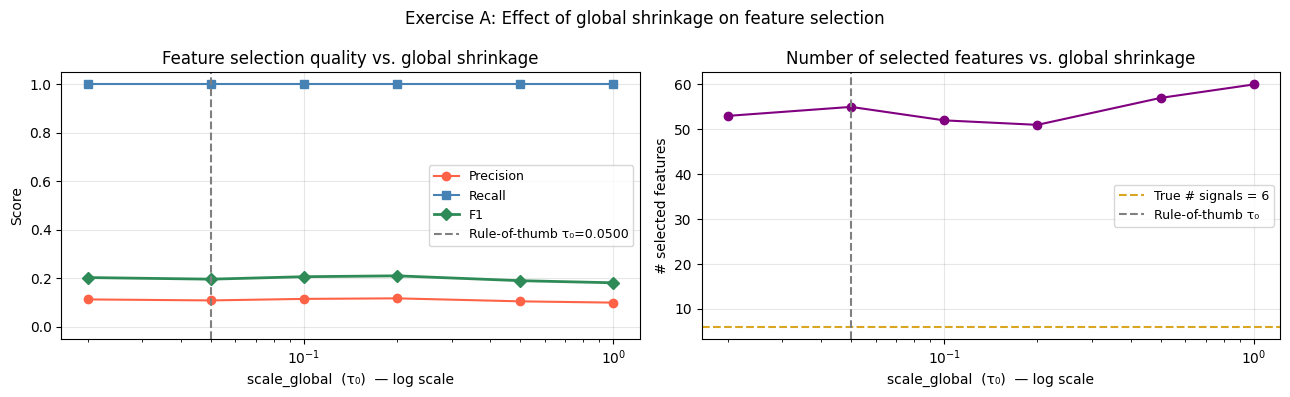


Takeaway:
  • Small τ₀ → aggressive shrinkage → higher precision but lower recall
  • Large τ₀ → relaxed shrinkage → higher recall but lower precision
  • The rule-of-thumb τ₀ ≈ 0.0500 balances the two


In [16]:
# ── Exercise A: sweep scale_global and track selection quality ────────────────
# NOTE: This sweep uses a short chain (num_warmup=150, num_samples=250) to
# keep total runtime reasonable.  For a real analysis use longer chains.

import warnings as _w

sweep_values = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
sweep_results = []

for sg in sweep_values:
    with _w.catch_warnings():
        _w.simplefilter("ignore")
        cfg_sweep = InferenceConfig(
            method="mcmc",
            num_warmup=150,
            num_samples=250,
            num_chains=2,
            use_gpu=use_gpu,
            progress_bar=False,
        )
    m = HorseshoeGLM(family="gaussian", scale_global=sg)
    m.fit(X, y, config=cfg_sweep)
    imp = m.get_feature_importance(method="beta", threshold=0.5)
    sel = imp.loc[imp["selected"], "feature_idx"].to_numpy()
    pm  = np.isin(np.arange(p), sel).astype(int)
    sweep_results.append({
        "scale_global": sg,
        "n_selected":   len(sel),
        "precision":    precision_score(true_mask, pm, zero_division=0),
        "recall":       recall_score(true_mask, pm, zero_division=0),
        "f1":           f1_score(true_mask, pm, zero_division=0),
    })
    print(f"  τ₀={sg:.3f}  → n_selected={len(sel):3d}  "
          f"P={sweep_results[-1]['precision']:.2f}  "
          f"R={sweep_results[-1]['recall']:.2f}  "
          f"F1={sweep_results[-1]['f1']:.2f}")

sweep_df = pd.DataFrame(sweep_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.semilogx(sweep_df["scale_global"], sweep_df["precision"],
            "o-", label="Precision", color="tomato")
ax.semilogx(sweep_df["scale_global"], sweep_df["recall"],
            "s-", label="Recall", color="steelblue")
ax.semilogx(sweep_df["scale_global"], sweep_df["f1"],
            "D-", label="F1", color="seagreen", lw=2)
# Mark the rule-of-thumb value
ax.axvline(scale_global, color="grey", ls="--", lw=1.5,
           label=f"Rule-of-thumb τ₀={scale_global:.4f}")
ax.set_xlabel("scale_global  (τ₀)  — log scale")
ax.set_ylabel("Score")
ax.set_title("Feature selection quality vs. global shrinkage")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

ax2 = axes[1]
ax2.semilogx(sweep_df["scale_global"], sweep_df["n_selected"],
             "o-", color="purple")
ax2.axhline(len(signal_idx), color="goldenrod", ls="--",
            lw=1.5, label=f"True # signals = {len(signal_idx)}")
ax2.axvline(scale_global, color="grey", ls="--", lw=1.5,
            label=f"Rule-of-thumb τ₀")
ax2.set_xlabel("scale_global  (τ₀)  — log scale")
ax2.set_ylabel("# selected features")
ax2.set_title("Number of selected features vs. global shrinkage")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle("Exercise A: Effect of global shrinkage on feature selection", fontsize=12)
plt.tight_layout()
plt.show()

print("\nTakeaway:")
print("  • Small τ₀ → aggressive shrinkage → higher precision but lower recall")
print("  • Large τ₀ → relaxed shrinkage → higher recall but lower precision")
print(f"  • The rule-of-thumb τ₀ ≈ {scale_global:.4f} balances the two")

## 7) Hands-on exercises and challenge prompts

Try these short activities to build intuition and discover practical tradeoffs.

### Exercise A — Sparsity calibration (global shrinkage)
1. Sweep `scale_global` over `[0.05, 0.1, 0.2, 0.5, 1.0]`.
2. Track precision/recall/F1 of selected features.
3. Explain the bias-variance tradeoff you observe.

### Exercise B — Signal-to-noise stress test
1. Keep the same true coefficients, vary `noise_sd` from `0.3` to `2.5`.
2. Plot recovery metrics vs noise level.
3. Identify where horseshoe starts missing weak signals.

### Exercise C — Correlated predictors (method limitation)
1. Create blocks of strongly correlated features.
2. Place a true signal in one feature per block.
3. Compare selection under `method='beta'`, `'lambda'`, and `'both'`.
4. Discuss why posterior mass can spread across correlated variables.

### Exercise D — p >> n scenario (state-of-the-art use case)
1. Set `n=80`, `p=500`, true signals = 8.
2. Use MCMC with fewer warmup/samples first, then increase.
3. Compare runtime, convergence, and recovery quality.

### Exercise E — Chain quality diagnostics
1. Intentionally set very short warmup/samples.
2. Use ArviZ to inspect R-hat, ESS, and trace behavior.
3. Propose a principled tuning plan to improve inference.

### Exercise F — Real-data challenge
1. Run the optional breast-cancer section with `RUN_REAL_DATA_DEMO=True`.
2. Rank features by inclusion probability.
3. Compare selected features to coefficients from a lasso baseline.
4. Reflect: when does Bayesian uncertainty add value over point-estimate methods?

### Exercise G — Prior robustness challenge
1. Replace true coefficients with one very large signal + several weak ones.
2. Evaluate whether regularized horseshoe retains weak effects while controlling noise.
3. Summarize pros/cons for scientific discovery vs pure prediction tasks.


## 8) Takeaways

- The horseshoe prior combines **aggressive noise shrinkage** with **heavy-tail signal retention**.
- MCMC gives richer uncertainty quantification for feature relevance than point-estimate methods.
- ArviZ diagnostics are essential before trusting selected features.
- Performance depends on prior scale, SNR, and predictor correlation structure.
